In [50]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing(as_frame=True)

X = housing['data']
y = housing['target']

/Users/josephparkes/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/josephparkes/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/josephparkes/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


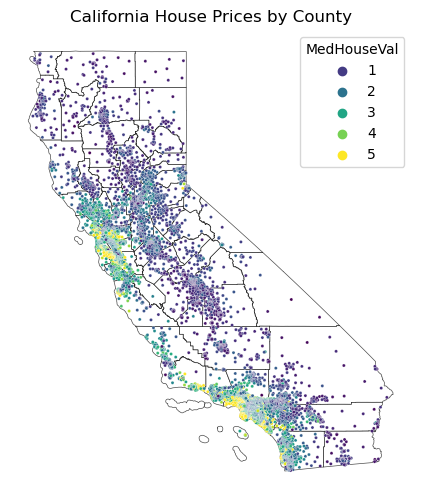

In [ ]:
import seaborn as sns
import geodatasets
import matplotlib.pyplot as plt
import geopandas as gpd

X_joined = X.join(y)
# California's state FIPS code is '06'
counties = gpd.read_file('https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip')
california_counties = counties[counties['STATEFP'] == '06']

fig, ax = plt.subplots(figsize=(6, 6))

# Plot county fills and borders
california_counties.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5, alpha=0.7)

# Overlay house prices
sns.scatterplot(data=X_joined, x='Longitude', y='Latitude',
                hue='MedHouseVal', ax=ax, s=5, palette='viridis')

plt.title("California House Prices")
plt.grid()
plt.axis('off')
plt.show()

Observe that there is a spatial element to house prices, this could just be correlative, expensive areas are filled with nice houses - however proximity to things like school districts, popular areas does also affect house prices

## Modelling

first we write a method that we will use when evaluating our models.

This function reports the R2 and plots a residuals plot, as well as the residuals distribution and spatially

In [24]:
from sklearn.model_selection import cross_val_score, train_test_split, KFold

kf = KFold(n_splits=5, shuffle=True)


def eval_model(model, X, y, plot=True):
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f'R^2 per fold: {scores}')
    print(f'Mean: {scores.mean():.3f} +/- {scores.std():.3f}')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    if plot:
        model.fit(X_train, y_train)
        y_preds = model.predict(X_test)
        residuals = y_test - y_preds
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Residuals vs predicted
        axes[0].scatter(y_preds, residuals, alpha=0.3, s=5)
        axes[0].axhline(0, color='red', linewidth=1)
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Residual')
        axes[0].set_title('Residuals vs Predicted')
        
        # Distribution of residuals
        axes[1].hist(residuals, bins=50)
        axes[1].set_title('Residual Distribution')
    
        residuals_X = X_test.copy()
        residuals_X['residual'] = residuals
        
        california_counties.plot(ax=axes[2], color='white', edgecolor='black', linewidth=0.5)
        
        scatter = axes[2].scatter(residuals_X['Longitude'], residuals_X['Latitude'],
                             c=residuals_X['residual'], cmap='RdBu',
                             alpha=0.9, s=5, vmin=-2, vmax=2)
        
        plt.colorbar(scatter, ax=axes[2], label='Residual')
        plt.title('Spatial Residuals')
        plt.axis('off')
        plt.show()

our first model is a Gradient Boosting model with no preprocessing. 

R^2 per fold: [0.84331538 0.83294986 0.843668   0.83485332 0.8318925 ]
Mean: 0.837 +/- 0.005


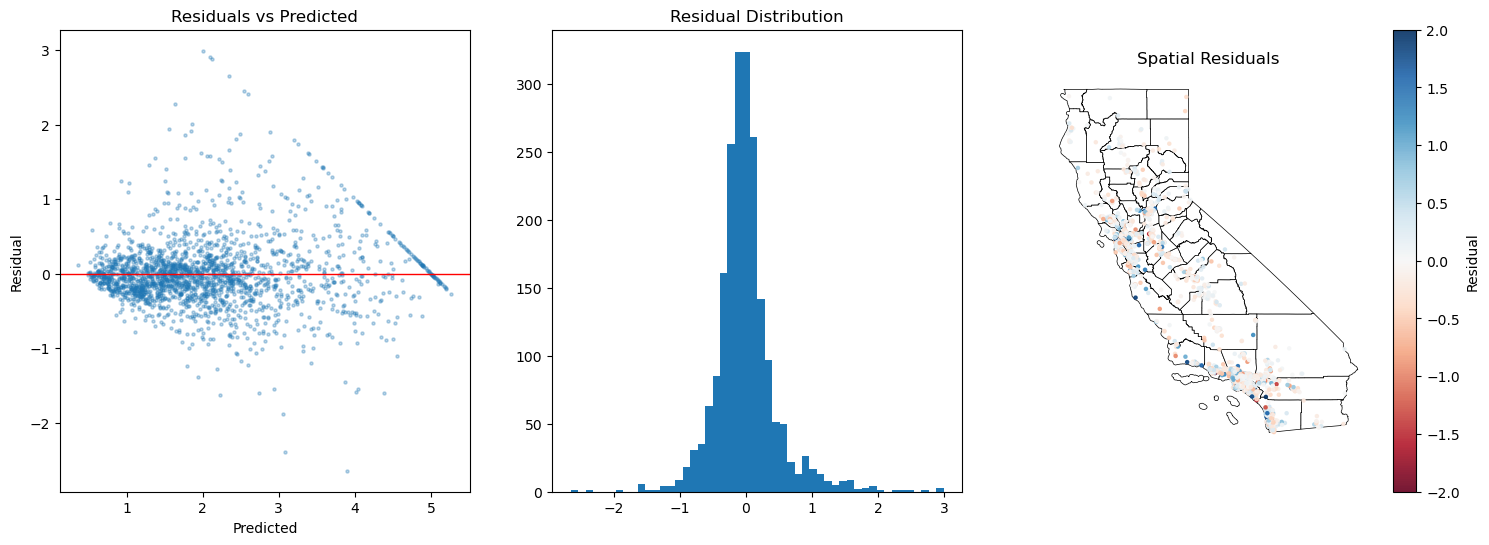

In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor()
eval_model(model, X, y)

lets compare this model to one without the spatial features

In [28]:
non_spatial_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

eval_model(model, X[non_spatial_features], y, plot=False)

R^2 per fold: [0.70404751 0.70638248 0.69787893 0.68466179 0.70756997]
Mean: 0.700 +/- 0.008


we can see that the gradient boosting model is able to utilise coordinates without any processing

## Linear Model vs KNeighborsRegression

The features Latitude and longitude which from the first plot will have some explanatory power

In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
lr = make_pipeline(MinMaxScaler(), RidgeCV(alphas=alphas))

spatial_features = ['Longitude', 'Latitude']
non_spatial_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

lr_non_spatial = make_pipeline(
    ColumnTransformer([
        ('spatial', MinMaxScaler(), non_spatial_features)],remainder='drop'),
    RidgeCV(alphas=alphas)

    )

print('Ridge with Spatial Features')
eval_model(lr, X, y, plot=False)
print('Ridge without Spatial Features')
eval_model(lr_non_spatial, X, y, plot=False)

Ridge with Spatial Features
R^2 per fold: [0.60867443 0.5929049  0.61796801 0.61277002 0.59067699]
Mean: 0.605 +/- 0.011
Ridge without Spatial Features
R^2 per fold: [0.50377933 0.56035279 0.5470915  0.53720105 0.51472523]
Mean: 0.533 +/- 0.021


A linear model is still able to use the coordinates however the marginal R^2 value is much smaller (0.07 vs 0.13). The Ridge can still utilise the Coordinates because there is a linear relationship between the east/west value

R^2 per fold: [0.79619475 0.79854146 0.79081573 0.79647521 0.80874655]
Mean: 0.798 +/- 0.006


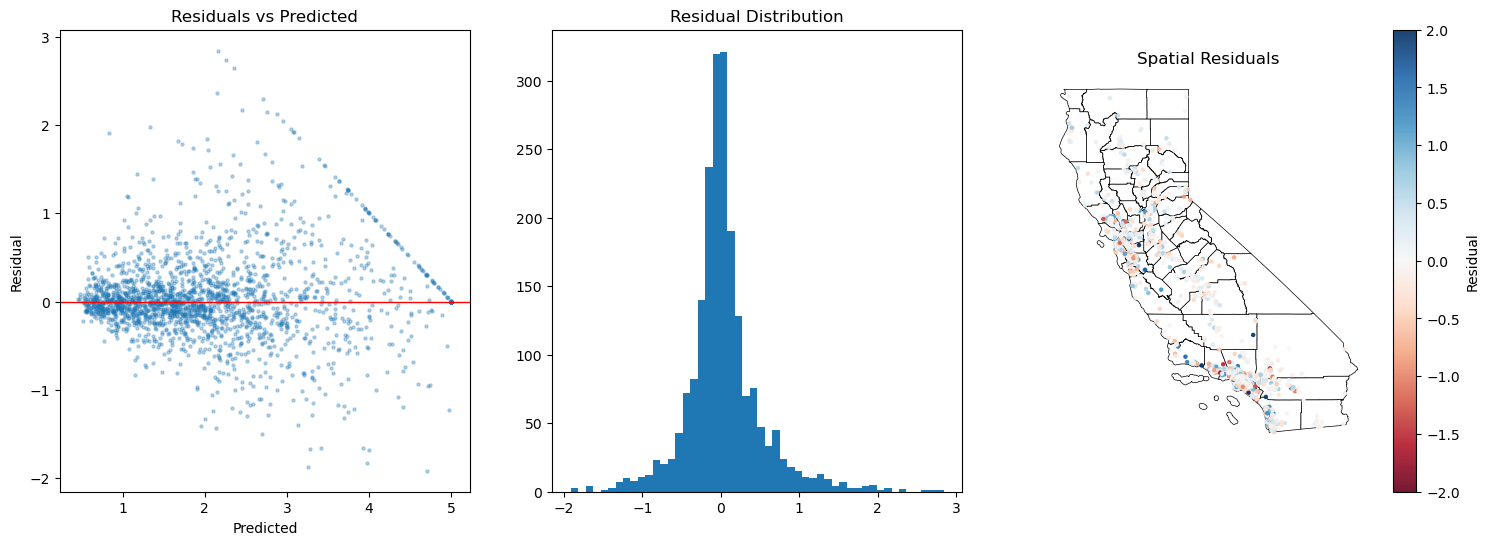

In [30]:
knn = make_pipeline(
    ColumnTransformer([('scale', MinMaxScaler(), ['Longitude', 'Latitude'])], remainder='drop',) ,
    KNeighborsRegressor(weights='uniform')
)

eval_model(knn, X, y)

however the performance of only using neighbors far exceeds this model. By using the outputs of the `KNeighborsRegressor` as a feature, we can make a Linear Model that is able to utilise spatial effects.

To do this we can use `TransformerMixin` to create our own Transformer

## Making a Neighbors Transformation

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin

class NeighborsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5, weights='uniform'):
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y):
        #print('y is None:', y is None)
        self.estimator_ = make_pipeline(
            MinMaxScaler(),
            KNeighborsRegressor(n_neighbors=self.n_neighbors, weights=self.weights)
        )
        self.estimator_.fit(X, y)
        return self

    def transform(self, X, y=None):
        return self.estimator_.predict(X).reshape(-1,1)

R^2 per fold: [0.81614122 0.8370027  0.84162094 0.83427448 0.82656806]
Mean: 0.831 +/- 0.009


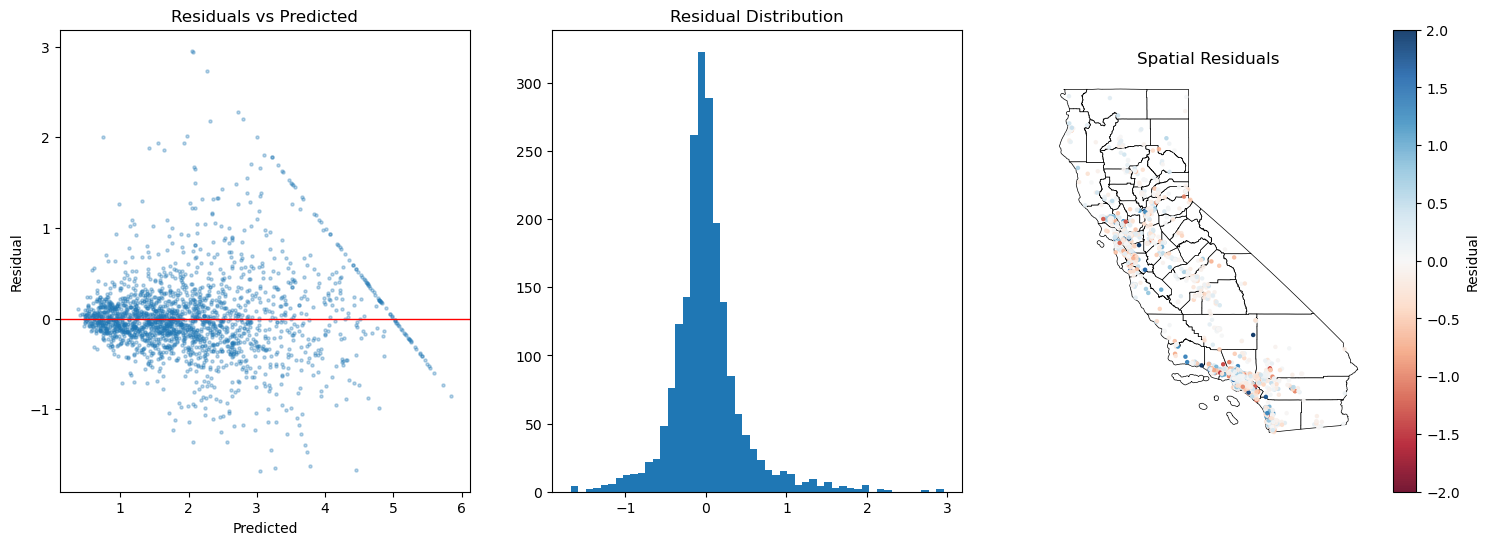

In [32]:
lr_model_with_neighbors = make_pipeline(
    ColumnTransformer([
        ('spatial', MinMaxScaler(), non_spatial_features),
        ('neighbors', NeighborsTransformer(), ['Longitude', 'Latitude'])]),
        RidgeCV(alphas=alphas)
)

eval_model(lr_model_with_neighbors, X, y)

utilising `NeighborsTransformer` the linear model can almost match the performance of gradient boosting model

R^2 per fold: [0.8413071  0.83899072 0.82470774 0.82988681 0.82474486]
Mean: 0.832 +/- 0.007


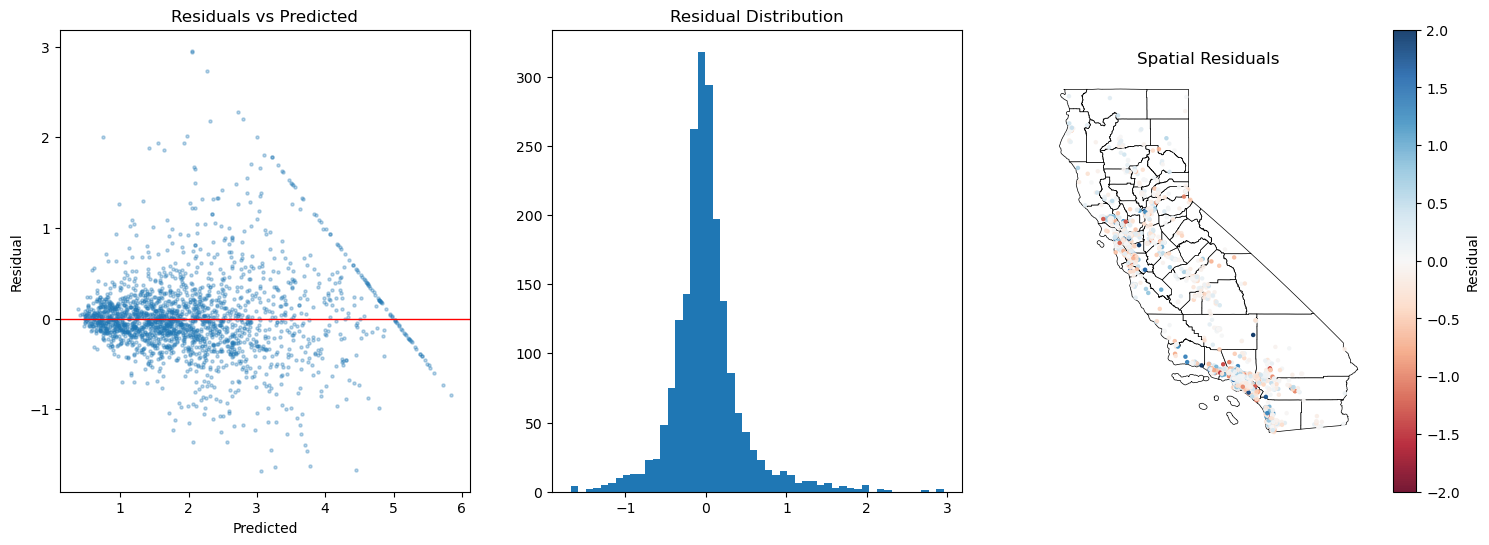

In [33]:
from sklearn.pipeline import FeatureUnion

neighbors_union = FeatureUnion([
    ('n5', NeighborsTransformer(n_neighbors=5)),
    ('n20', NeighborsTransformer(n_neighbors=20))
])

lr_model_with_neighbors_union = make_pipeline(
    ColumnTransformer([
        ('spatial', MinMaxScaler(), non_spatial_features),
        ('neighbors', neighbors_union, ['Longitude', 'Latitude'])])
    ,RidgeCV(alphas=alphas)
)

eval_model(lr_model_with_neighbors_union, X, y)

utilising multiple levels of Neighbors doesn't improve the performance

R^2 per fold: [0.8460366  0.85205571 0.84533776 0.85016228 0.84523562]
Mean: 0.848 +/- 0.003


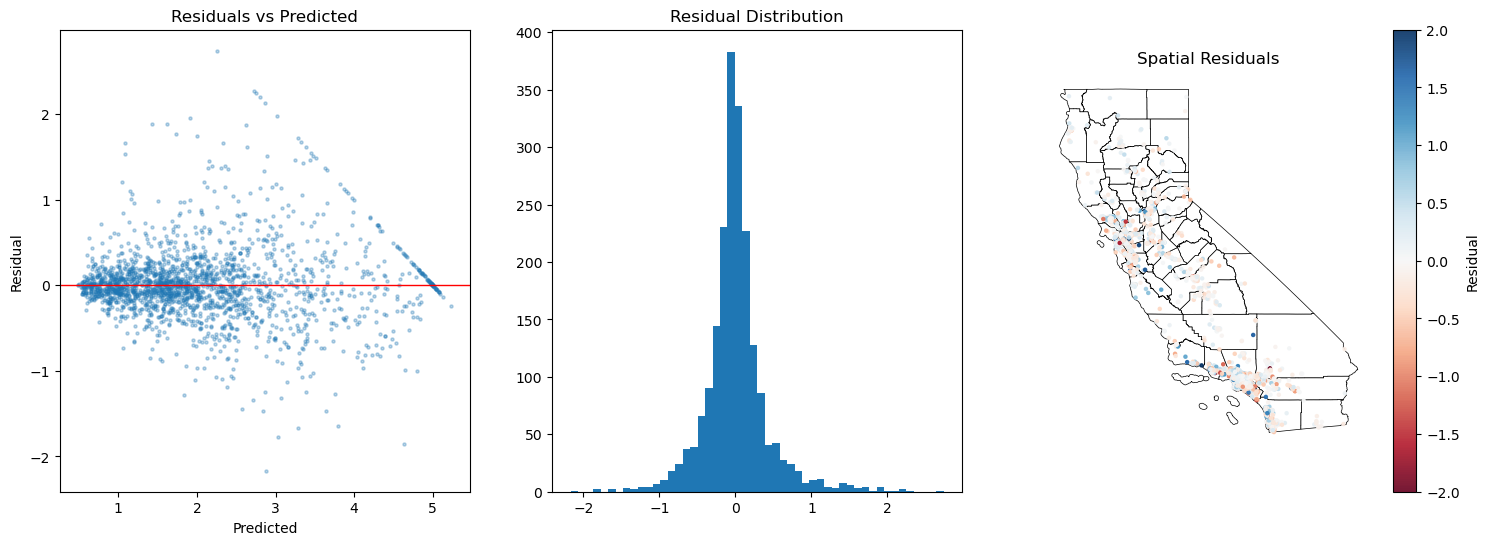

In [34]:
gb_model_neighbors = make_pipeline(
    ColumnTransformer([
        ('non_spatial', 'passthrough', non_spatial_features),
        ('neighbors', NeighborsTransformer(), ['Longitude', 'Latitude'])])
    ,HistGradientBoostingRegressor()
)

eval_model(gb_model_neighbors, X, y)

using the `NeighborsTransformer` increases the performance of the Gradient Boosting model also!

R^2 per fold: [0.85847156 0.85622496 0.85702648 0.85846408 0.85495963]
Mean: 0.857 +/- 0.001


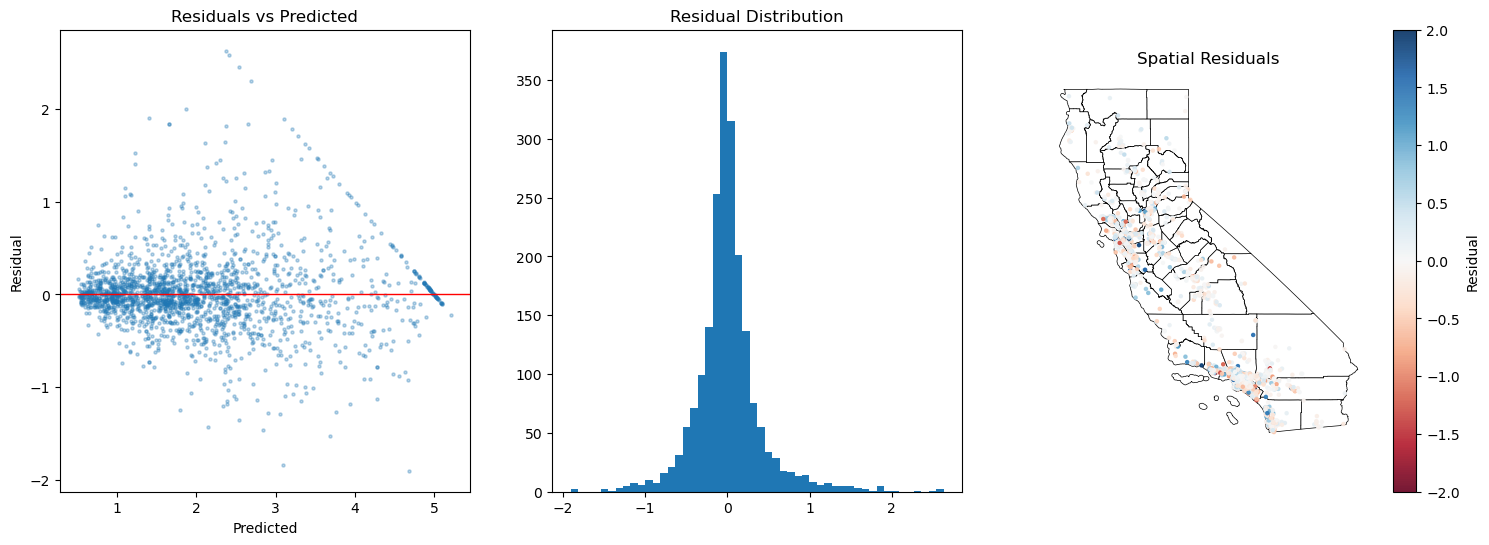

In [35]:
from sklearn.pipeline import FunctionTransformer

gb_model_neighbors_and_raw = make_pipeline(
    ColumnTransformer([
        ('non_spatial', 'passthrough', non_spatial_features),
        ('neighbors', 
         FeatureUnion(
            [
                ('neighbors', NeighborsTransformer(n_neighbors=5)),
                ('raw', FunctionTransformer())
            ]
        ), ['Longitude', 'Latitude'])])
    ,HistGradientBoostingRegressor()
)

eval_model(gb_model_neighbors_and_raw, X, y)

Using both raw and transformed makes the model perform better still!

To use the spatial information without processing may require more complex models. We can test this by observing the performance of the model at different tree depths with and without the neighbors transformer. A point to observe is that when train/predict time is significant, using this transformation can have significant benefits!

In [36]:
from timeit import default_timer as timer

depths = [2, 3, 5, 10, 20, None]
results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths:
    raw_model = HistGradientBoostingRegressor(max_depth=depth)
    
    knn_ct = ColumnTransformer([
        ('non_spatial', 'passthrough', non_spatial_features),
        (
            'neighbors', 
            FeatureUnion(
             [
                ('neighbors', NeighborsTransformer(n_neighbors=5)),
                ('raw', FunctionTransformer())
             ]), 
            ['Longitude', 'Latitude']
        )
    ])
    knn_model = make_pipeline(knn_ct, HistGradientBoostingRegressor(max_depth=depth))
    
    print(f'Depth: {depth}')
    
    time_start = timer()
    raw_r2 = cross_val_score(raw_model, X, y, cv=kf, scoring='r2').mean()
    raw_time = timer() - time_start
    
    time_start = timer()
    knn_r2 = cross_val_score(knn_model, X, y, cv=kf, scoring='r2').mean()
    knn_time = timer() - time_start
    
    results.append({
        'depth': str(depth), 
        'raw_r2': raw_r2, 
        'knn_r2': knn_r2,
        'raw_time': round(raw_time, 2),
        'knn_time': round(knn_time, 2)
    })

results_df = pd.DataFrame(results)
results_df['r2_difference'] = results_df['knn_r2'] - results_df['raw_r2']
results_df['time_difference'] = results_df['knn_time'] - results_df['raw_time']

results_df

Depth: 2
Depth: 3
Depth: 5
Depth: 10
Depth: 20
Depth: None


,depth,raw_r2,knn_r2,raw_time,knn_time,r2_difference,time_difference
0,2,0.752936,0.840858,0.60,0.74,0.087922,0.14
1,3,0.788209,0.849068,1.70,2.48,0.060859,0.78
2,5,0.823047,0.855770,8.88,7.44,0.032723,-1.44
3,10,0.835975,0.858438,11.86,12.68,0.022463,0.82
4,20,0.836228,0.856802,10.71,7.35,0.020574,-3.36
5,None,0.836577,0.855466,9.88,9.82,0.018889,-0.06


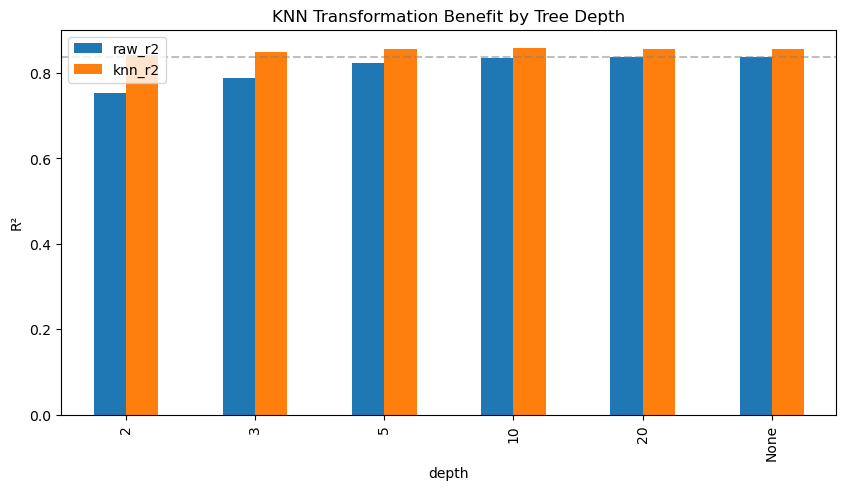

In [39]:
results_df.plot(x='depth', y=['raw_r2', 'knn_r2'], kind='bar', figsize=(10, 5))
plt.ylabel('R²')
plt.title('KNN Transformation Benefit by Tree Depth')
plt.axhline(y=results_df['raw_r2'].max(), color='grey', linestyle='--', alpha=0.5)
plt.show()